# Lab 01 — Data Loading and Preprocessing

**Goal:** practice loading a small tabular dataset, inspecting it, handling missing values, and producing the three core visualizations (scatter, histogram, line) on a real dataset.

**Dataset:** Iris (loaded from `sklearn.datasets`).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

SEED = 42
rng = np.random.default_rng(SEED)

## 2. Load and inspect

Each row is one flower; columns are 4 measurements + a target species id.

In [2]:
data = load_iris(as_frame=True)
df = data.frame.copy()
df['species'] = df['target'].map(dict(enumerate(data.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print('shape  :', df.shape)
print('dtypes :')
print(df.dtypes)
df.describe()

shape  : (150, 6)
dtypes :
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 3. Inject and handle missing values

Iris has none, so let's simulate by knocking out 5% of `petal length (cm)` at random — then practice both **dropping** and **imputing**.

In [4]:
df_missing = df.copy()
mask = rng.random(len(df_missing)) < 0.05
df_missing.loc[mask, 'petal length (cm)'] = np.nan
print('missing values:')
print(df_missing.isna().sum())

missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    7
petal width (cm)     0
target               0
species              0
dtype: int64


In [5]:
df_dropped = df_missing.dropna(subset=['petal length (cm)']).reset_index(drop=True)
df_filled  = df_missing.copy()
df_filled['petal length (cm)'] = df_filled['petal length (cm)'].fillna(
    df_filled['petal length (cm)'].mean()
)
print('after drop  :', df_dropped.shape)
print('after fill  :', df_filled.shape)

after drop  : (143, 6)
after fill  : (150, 6)


## 4. Three visualizations

### 4.1 Scatter — features vs features, colored by class

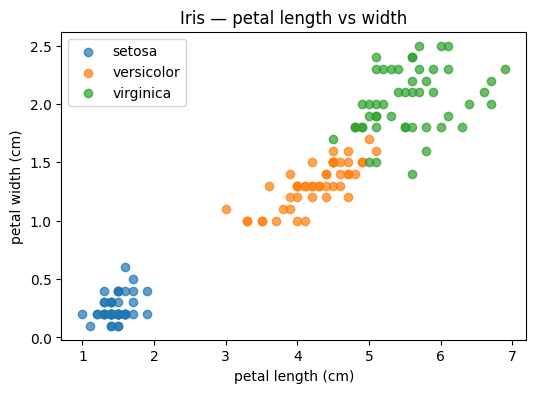

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for species in df['species'].unique():
    sub = df[df['species'] == species]
    ax.scatter(sub['petal length (cm)'], sub['petal width (cm)'],
               label=species, alpha=0.7)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')
ax.set_title('Iris — petal length vs width')
ax.legend()
plt.show()

### 4.2 Histogram — single-feature distribution by class

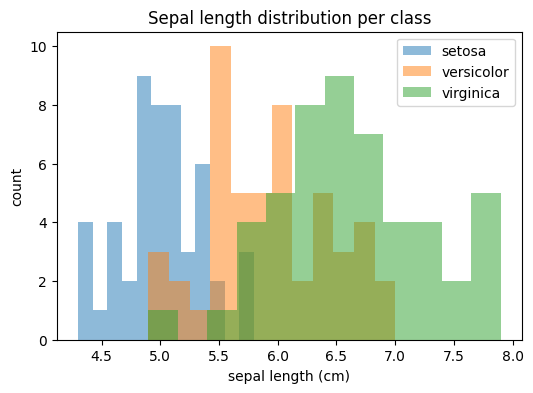

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for species in df['species'].unique():
    sub = df[df['species'] == species]
    ax.hist(sub['sepal length (cm)'], bins=12, alpha=0.5, label=species)
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('count')
ax.set_title('Sepal length distribution per class')
ax.legend()
plt.show()

### 4.3 Line — running mean per index

A line plot is most useful for ordered data. Here we cheat slightly: we sort by petal length and plot a running mean of petal width — useful purely as a line-plot exercise.

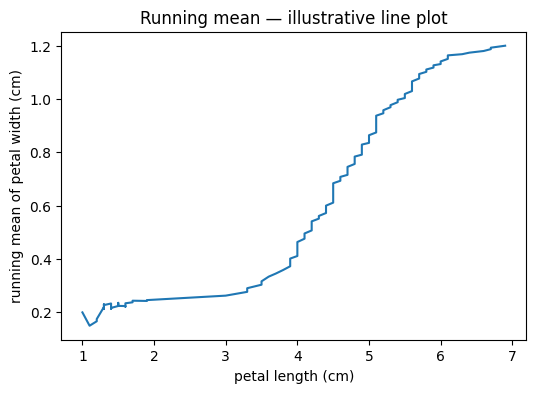

In [8]:
sorted_df = df.sort_values('petal length (cm)').reset_index(drop=True)
running_mean = sorted_df['petal width (cm)'].expanding().mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sorted_df['petal length (cm)'], running_mean)
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('running mean of petal width (cm)')
ax.set_title('Running mean — illustrative line plot')
plt.show()

## 5. Summary

- A DataFrame's `.shape`, `.dtypes`, `.describe()`, `.isna()` give you a sense of the data in five lines.
- Missing values are handled either by **dropping** rows / columns or by **imputing** a sensible value (e.g. column mean).
- Scatter, hist, line plots are enough for an initial EDA.

**Next:** apply this same loop to a dataset of your choice in `assignments/assignment_01_csv_eda.ipynb`.